# 데이터프레임 결측치 처리(1)

1) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 1-1) pandas 라이브러리를 pd 별칭을 주어 불러오세요.
- 1-2) 다음 파일을 읽어와 titanic 데이터프레임을 선언하세요.
    - 파일 : 'titanic_train.csv'
- 1-3) PassengerId, Name,Ticket, Cabin 열을 한 번에 제거하세요.

In [1]:
import pandas as pd
import numpy as np

2) 상위 5개 행을 확인하세요.

In [2]:
path = '../실습_data/titanic_train.csv'
ttc = pd.read_csv(path) 

ttc.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
ttc.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
ttc

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


3) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 3-1) Age 열 결측치를 Age 열 평균으로 채우세요.
- 3-2) Embarked 열 결측치를 'S'로 채우세요.
- 3-3) 각 열에 결측치가 남아있는지 확인하세요.

In [4]:
# 3-1) Age 열 결측치를 Age 열 평균으로 채우기
ttc['Age'] = ttc['Age'].fillna(ttc['Age'].mean())
ttc['Age']

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [5]:
# 3-2) Embarked 열 결측치를 'S'로 채우기
ttc['Embarked'] = ttc['Embarked'].fillna('S')
ttc

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


In [6]:
# 3-3) 각 열에 결측치가 남아있는지 확인하기
ttc.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

4) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 4-1) groupby 메소드를 사용해 Pclass 별 탑승자 수를 집계하여 tmp 데이터프레임으로 선언하세요.
    - Survived 열 count() 집계
- 4-2) tmp 데이터프레임 열 이름이 Pclass, Count가 되게 변경하세요.
- 4-3) tmp 데이터프레임을 막대 그래프로 시각화해 확인하세요.

In [10]:
tmp = ttc.groupby(by='Pclass')[['Survived']].count()
tmp


,Survived
Pclass,
1,216
2,184
3,491


In [12]:
tmp = tmp.reset_index()
tmp.columns = ['Pclass', 'Count']

<Axes: xlabel='Pclass'>

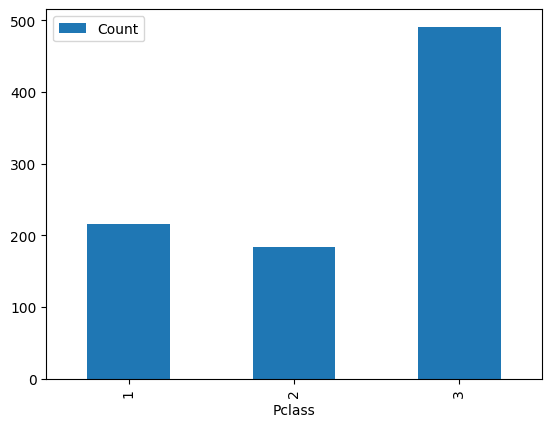

In [13]:
tmp.plot(kind='bar', x='Pclass', y='Count')

5) Pclass, Sex, Embarked 열을 한 번에 가변수화하세요. 단, 다중공선성 문제가 없도록 범주값 개수보다 하나 적은 수의 열이 만들어지게 하세요.